In [2]:
import sqlite3

In [4]:
import pandas as pd

In [8]:
import matplotlib.pyplot as plt

In [10]:
conn = sqlite3.connect("sales_data.db")

In [14]:
cursor = conn.cursor()

In [16]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    date TEXT,
    product TEXT,
    category TEXT,
    quantity INTEGER,
    price REAL
)
""")

In [18]:
sample_data = [
    ('2025-05-01', 'Apples', 'Fruits', 10, 2.5),
    ('2025-05-01', 'Oranges', 'Fruits', 8, 3.0),
    ('2025-05-02', 'Bananas', 'Fruits', 15, 1.8),
    ('2025-05-02', 'Milk', 'Dairy', 4, 4.5),
    ('2025-05-03', 'Cheese', 'Dairy', 3, 6.0),
    ('2025-05-03', 'Apples', 'Fruits', 5, 2.5),
    ('2025-05-04', 'Oranges', 'Fruits', 12, 3.0),
    ('2025-05-04', 'Yogurt', 'Dairy', 7, 2.8),
]

In [20]:
cursor.executemany("INSERT INTO sales (date, product, category, quantity, price) VALUES (?, ?, ?, ?, ?)", sample_data)
conn.commit()

In [42]:
query_product = """
SELECT 
    product, 
    SUM(quantity) AS total_qty, 
    (SUM(quantity * price) AS revenue 
FROM sales 
GROUP BY product
"""

In [24]:
df_product = pd.read_sql_query(query_product, conn)
print("\n Sales Summary by Product:")
print(df_product)


 Sales Summary by Product:
   product  total_qty  revenue
0   Apples         15     37.5
1  Bananas         15     27.0
2   Cheese          3     18.0
3     Milk          4     18.0
4  Oranges         20     60.0
5   Yogurt          7     19.6


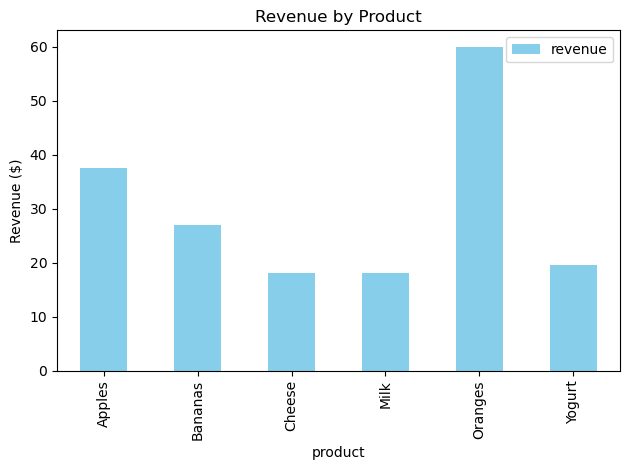

In [60]:
df_product.plot(kind='bar', x='product', y='revenue', title='Revenue by Product', color='skyblue')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.savefig("sample_chart3.png")
plt.show()


 Daily Revenue Trend:
         date  daily_revenue
0  2025-05-01           49.0
1  2025-05-02           45.0
2  2025-05-03           30.5
3  2025-05-04           55.6


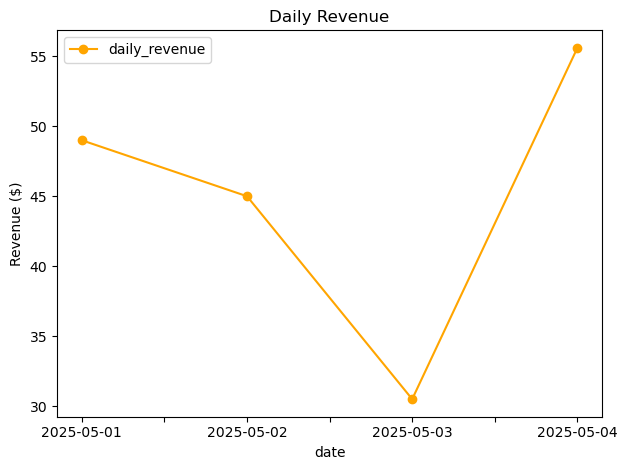

In [58]:
query_date = """
SELECT 
    date,
    SUM(quantity * price) AS daily_revenue
FROM sales
GROUP BY date
ORDER BY date
"""

df_date = pd.read_sql_query(query_date, conn)
print("\n Daily Revenue Trend:")
print(df_date)

df_date.plot(x='date', y='daily_revenue', kind='line', marker='o', title='Daily Revenue', color='orange')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.savefig("sample_chart1.png")
plt.show()


 Category Summary:
  category  total_qty  revenue
0    Dairy         14     55.6
1   Fruits         50    124.5


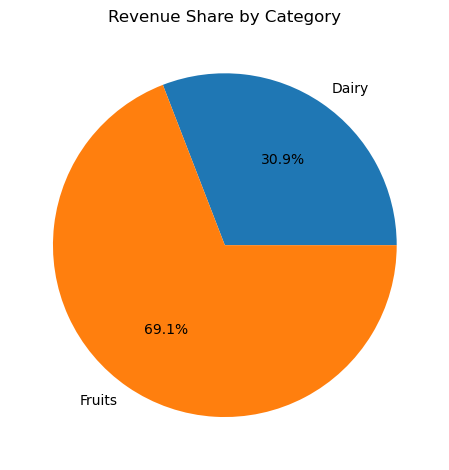

In [56]:
query_category = """
SELECT category, SUM(quantity) AS total_qty,SUM(quantity * price) AS revenue
FROM sales
GROUP BY category
"""
df_cat = pd.read_sql_query(query_category, conn)
print("\n Category Summary:")
print(df_cat)

df_cat.plot(kind='pie', y='revenue', labels=df_cat['category'], autopct='%1.1f%%', legend=False)
plt.title('Revenue Share by Category')
plt.ylabel('')
plt.tight_layout()
plt.savefig("sample_chart.png")
plt.show()